<a href="https://colab.research.google.com/github/geeta781/student-mental-health-app/blob/main/FINAL_MERGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FINAL MERGE — Augmentation Pipeline
## Combines all steps → Dedup → Balance → AUGMENTED_FINAL.csv

| Input Files | Rows |
|---|---|
| step0_extended.csv | 7,182 |
| step2_eda.csv | 26,622 |
| step4_contextual.csv | 9,793 |
| step5_anger_final.csv | 791 |
| **Total raw** | **44,388** |
| **Target output** | **34,290 (5,715 × 6)** |

### What this notebook does:
1. Loads all 4 step files from Google Drive
2. Combines into one dataframe
3. Removes exact duplicate utterances
4. Removes near-duplicates using SBERT (cosine > 0.97)
5. Balances each class to exactly 5,715 rows
6. Saves AUGMENTED_FINAL.csv + verification plots
7. Downloads to your computer


In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')
DRIVE = '/content/drive/MyDrive/emotion_augmentation/'
os.makedirs(DRIVE, exist_ok=True)
print('Drive mounted:', DRIVE)


Mounted at /content/drive
Drive mounted: /content/drive/MyDrive/emotion_augmentation/


In [2]:
import subprocess, sys
for p in ['sentence-transformers', 'scikit-learn',
          'pandas', 'numpy', 'tqdm', 'matplotlib']:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',p])
print('Packages ready')


Packages ready


In [3]:
import pandas as pd
import numpy as np
import os, json, warnings
from tqdm import tqdm
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
warnings.filterwarnings('ignore')

DRIVE            = '/content/drive/MyDrive/emotion_augmentation/'
TARGET_PER_CLASS = 5715
DEDUP_THRESHOLD  = 0.97   # remove if similarity > this
OUTPUT_FINAL     = DRIVE + 'AUGMENTED_FINAL.csv'
OUTPUT_LOG       = DRIVE + 'augmentation_log.json'
OUTPUT_FIG       = DRIVE + 'augmentation_verification.png'

EMOTIONS = ['Joy', 'Sadness', 'Anger', 'Fear', 'Disgust', 'Surprise']

print('Config loaded')
print(f'Target per class : {TARGET_PER_CLASS:,}')
print(f'Target total     : {TARGET_PER_CLASS * 6:,}')
print(f'Output           : {OUTPUT_FINAL}')


Config loaded
Target per class : 5,715
Target total     : 34,290
Output           : /content/drive/MyDrive/emotion_augmentation/AUGMENTED_FINAL.csv


In [5]:
step_files = {
    'step0_extended.csv'   : 'Step 0 - Extension',
    'step2_eda.csv'        : 'Step 2 - EDA',
    'step4_contextual.csv' : 'Step 4 - Contextual BERT',
    'step5_anger_COMBINED.csv': 'Step 5 - LLM Anger',
}

all_dfs = []
print('Loading files...')
print('='*50)

for fname, label in step_files.items():
    fpath = DRIVE + fname
    if os.path.exists(fpath):
        df_t = pd.read_csv(fpath)
        # Standardise columns
        if 'word_count' not in df_t.columns:
            df_t['word_count'] = df_t['utterance'].str.split().str.len()
        if 'aug_method' not in df_t.columns:
            df_t['aug_method'] = 'original'
        if 'sbert_sim' not in df_t.columns:
            df_t['sbert_sim'] = 1.0
        all_dfs.append(df_t)
        print(f'  {label:<35}: {len(df_t):>6,} rows')
    else:
        print(f'  NOT FOUND: {fname} — skipping')

combined = pd.concat(all_dfs, ignore_index=True)
combined['word_count'] = combined['utterance'].str.split().str.len()

print()
print(f'Total combined: {len(combined):,} rows')
print()
print('Per-class raw counts:')
counts = combined['emotion_label'].value_counts()
for emo in EMOTIONS:
    c = counts.get(emo, 0)
    print(f'  {emo:<10}: {c:>6,}')


Loading files...
  Step 0 - Extension                 :  7,182 rows
  Step 2 - EDA                       : 26,622 rows
  Step 4 - Contextual BERT           :  9,793 rows
  Step 5 - LLM Anger                 :    791 rows

Total combined: 44,388 rows

Per-class raw counts:
  Joy       :  7,065
  Sadness   :  5,858
  Anger     :  5,716
  Fear      :  8,592
  Disgust   :  9,152
  Surprise  :  8,005


In [6]:
print('Step 1: Exact deduplication...')
before = len(combined)
combined = combined.drop_duplicates(subset=['utterance'])
after = len(combined)
print(f'  Removed {before - after:,} exact duplicates')
print(f'  Remaining: {after:,} rows')


Step 1: Exact deduplication...
  Removed 109 exact duplicates
  Remaining: 44,279 rows


In [7]:
print('Loading SBERT for near-duplicate removal...')
sbert = SentenceTransformer('all-MiniLM-L6-v2')
print('SBERT ready')
print()
print('Step 2: Near-duplicate removal per class (threshold:', DEDUP_THRESHOLD, ')')
print('This protects all originals and removes only highly similar augmented rows.')
print()

final_dfs = []

for emotion in EMOTIONS:
    subset = combined[combined['emotion_label'] == emotion].reset_index(drop=True)
    print(f'Processing {emotion}: {len(subset):,} rows...')

    # Always keep originals
    originals  = subset[subset['aug_method'] == 'original'].copy()
    augmented  = subset[subset['aug_method'] != 'original'].copy()

    kept = originals.copy()

    if len(augmented) > 0 and len(kept) > 0:
        # Encode kept utterances
        kept_embs = sbert.encode(
            kept['utterance'].tolist(),
            batch_size=128, show_progress_bar=False
        )

        kept_list  = kept.to_dict('records')
        kept_texts = kept['utterance'].tolist()

        for _, aug_row in tqdm(augmented.iterrows(),
                               total=len(augmented),
                               desc=f'  {emotion}',
                               leave=False):
            aug_emb = sbert.encode([aug_row['utterance']])
            sims    = cosine_similarity(aug_emb, kept_embs)[0]

            if sims.max() < DEDUP_THRESHOLD:
                kept_list.append(aug_row.to_dict())
                kept_embs = np.vstack([kept_embs, aug_emb])

        kept = pd.DataFrame(kept_list)

    final_dfs.append(kept)
    print(f'  {emotion}: {len(subset):,} -> {len(kept):,} after near-dedup')

df_deduped = pd.concat(final_dfs, ignore_index=True)
print()
print(f'After near-dedup: {len(df_deduped):,} rows')


Loading SBERT for near-duplicate removal...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

  Sadness: 5,858 -> 4,361 after near-dedup
Processing Anger: 5,716 rows...


  Anger: 5,716 -> 4,527 after near-dedup
Processing Fear: 8,562 rows...


  Fear: 8,562 -> 6,488 after near-dedup
Processing Disgust: 9,105 rows...


  Disgust: 9,105 -> 6,826 after near-dedup
Processing Surprise: 7,973 rows...


  Surprise: 7,973 -> 6,354 after near-dedup

After near-dedup: 33,773 rows


In [8]:
print('Step 3: Balancing each class to', TARGET_PER_CLASS, 'rows...')
print()

balanced_dfs = []
balance_log  = {}

for emotion in EMOTIONS:
    subset   = df_deduped[df_deduped['emotion_label'] == emotion]
    originals = subset[subset['aug_method'] == 'original']
    augmented = subset[subset['aug_method'] != 'original']

    n_available = len(subset)
    n_orig      = len(originals)

    if n_available >= TARGET_PER_CLASS:
        # Keep all originals + sample augmented to fill target
        n_aug_needed = TARGET_PER_CLASS - n_orig
        if n_aug_needed > 0 and len(augmented) > 0:
            aug_sample = augmented.sample(
                min(n_aug_needed, len(augmented)),
                random_state=42
            )
            balanced = pd.concat([originals, aug_sample], ignore_index=True)
        else:
            balanced = originals.sample(
                min(TARGET_PER_CLASS, n_orig),
                random_state=42
            )
    else:
        # Use everything available
        balanced = subset.copy()

    balanced_dfs.append(balanced)
    balance_log[emotion] = {
        'available' : int(n_available),
        'originals' : int(n_orig),
        'final'     : int(len(balanced)),
        'target'    : TARGET_PER_CLASS
    }

    diff   = len(balanced) - TARGET_PER_CLASS
    status = f'+{diff}' if diff >= 0 else str(diff)
    print(f'  {emotion:<10}: {n_available:>6,} avail -> {len(balanced):>5,} kept  ({status})')

df_final = pd.concat(balanced_dfs, ignore_index=True)
df_final = df_final.reset_index(drop=True)

# Assign clean utterance IDs
df_final['utterance_id'] = ['AUG_' + str(i+1).zfill(6) for i in range(len(df_final))]

print()
print(f'Final dataset: {len(df_final):,} rows')


Step 3: Balancing each class to 5715 rows...

  Joy       :  5,217 avail -> 5,217 kept  (-498)
  Sadness   :  4,361 avail -> 4,361 kept  (-1354)
  Anger     :  4,527 avail -> 4,527 kept  (-1188)
  Fear      :  6,488 avail -> 5,715 kept  (+0)
  Disgust   :  6,826 avail -> 5,715 kept  (+0)
  Surprise  :  6,354 avail -> 5,715 kept  (+0)

Final dataset: 31,250 rows


In [9]:
# Save final CSV
df_final.to_csv(OUTPUT_FINAL, index=False)

# Save log
log = {
    'total_rows'       : int(len(df_final)),
    'target_per_class' : TARGET_PER_CLASS,
    'class_distribution': {k: int(v['final']) for k, v in balance_log.items()},
    'augmentation_methods': {
        k: int(v)
        for k, v in df_final['aug_method'].value_counts().items()
    },
    'avg_word_count'   : round(float(df_final['word_count'].mean()), 1),
    'exact_duplicates' : int(df_final.duplicated(subset=['utterance']).sum()),
}

with open(OUTPUT_LOG, 'w') as f:
    json.dump(log, f, indent=2)

print('Files saved:')
print(f'  {OUTPUT_FINAL}')
print(f'  {OUTPUT_LOG}')
print()
print('=== FINAL STATISTICS ===')
print(f'Total rows     : {len(df_final):,}')
print(f'Avg word count : {df_final["word_count"].mean():.1f}')
print(f'Duplicates     : {df_final.duplicated(subset=["utterance"]).sum()}')
print()
print('Class distribution:')
final_counts = df_final['emotion_label'].value_counts()
for emo in EMOTIONS:
    c = final_counts.get(emo, 0)
    print(f'  {emo:<10}: {c:>5,}')
print()
print('Augmentation method breakdown:')
print(df_final['aug_method'].value_counts().to_string())


Files saved:
  /content/drive/MyDrive/emotion_augmentation/AUGMENTED_FINAL.csv
  /content/drive/MyDrive/emotion_augmentation/augmentation_log.json

=== FINAL STATISTICS ===
Total rows     : 31,250
Avg word count : 32.1
Duplicates     : 0

Class distribution:
  Joy       : 5,217
  Sadness   : 4,361
  Anger     : 4,527
  Fear      : 5,715
  Disgust   : 5,715
  Surprise  : 5,715

Augmentation method breakdown:
aug_method
original           7182
contextual_bert    6233
eda_SR             5887
eda_RS             4393
eda_RI             3706
eda_RD             3058
llm_claude          582
llm_external        209


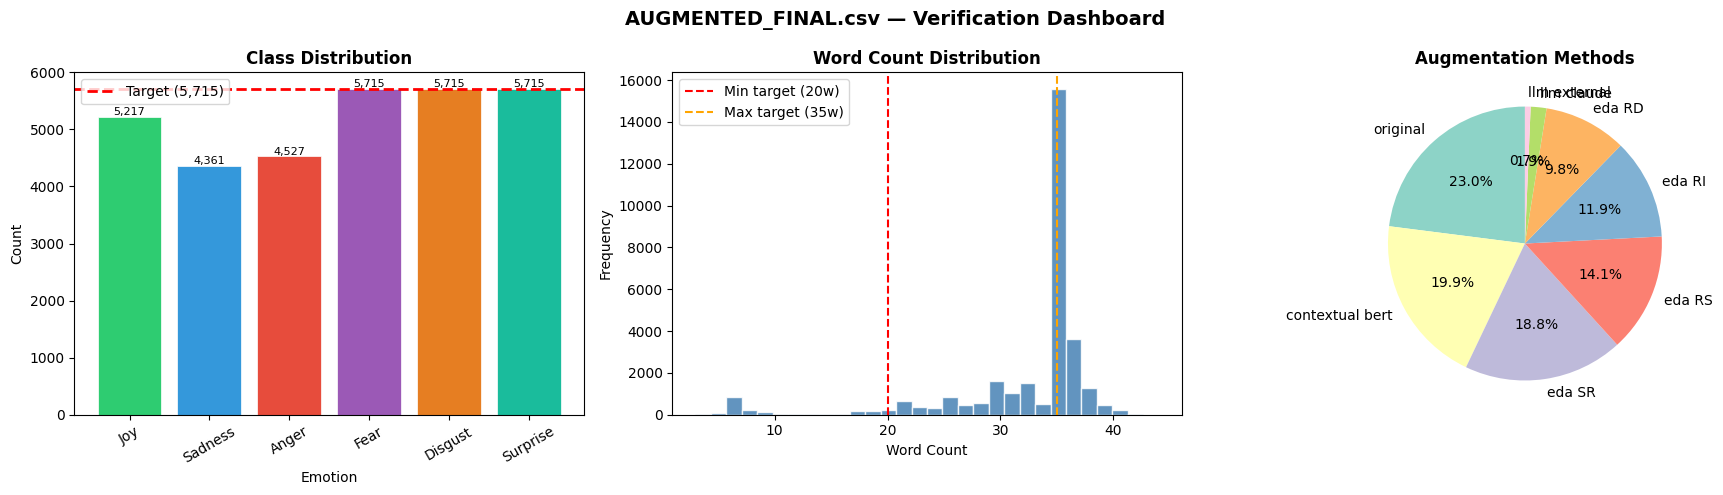

Figure saved: /content/drive/MyDrive/emotion_augmentation/augmentation_verification.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AUGMENTED_FINAL.csv — Verification Dashboard',
             fontsize=14, fontweight='bold')

# Plot 1: Class distribution
dist   = df_final['emotion_label'].value_counts().reindex(EMOTIONS)
colors = ['#2ecc71','#3498db','#e74c3c','#9b59b6','#e67e22','#1abc9c']
axes[0].bar(dist.index, dist.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(y=TARGET_PER_CLASS, color='red', linestyle='--',
                linewidth=2, label=f'Target ({TARGET_PER_CLASS:,})')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)
for i, (emo, val) in enumerate(zip(dist.index, dist.values)):
    axes[0].text(i, val + 30, f'{val:,}', ha='center', fontsize=8)

# Plot 2: Word count distribution
axes[1].hist(df_final['word_count'], bins=30,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(x=20, color='red',    linestyle='--', label='Min target (20w)')
axes[1].axvline(x=35, color='orange', linestyle='--', label='Max target (35w)')
axes[1].set_title('Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Plot 3: Augmentation method breakdown
method_counts = df_final['aug_method'].value_counts()
axes[2].pie(method_counts.values,
            labels=[m.replace('_', ' ') for m in method_counts.index],
            autopct='%1.1f%%', startangle=90,
            colors=plt.cm.Set3.colors[:len(method_counts)])
axes[2].set_title('Augmentation Methods', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=300, bbox_inches='tight')
plt.show()
print(f'Figure saved: {OUTPUT_FIG}')


In [11]:
import os
from google.colab import files

print('=== DOWNLOAD FILES ===')
for fpath, label in [
    (OUTPUT_FINAL, 'AUGMENTED_FINAL.csv'),
    (OUTPUT_LOG,   'augmentation_log.json'),
    (OUTPUT_FIG,   'augmentation_verification.png'),
]:
    if os.path.exists(fpath):
        size = os.path.getsize(fpath)
        print(f'Downloading {label} ({size/1024/1024:.1f} MB)...')
        files.download(fpath)
    else:
        print(f'NOT FOUND: {fpath}')

print()
print('All downloads complete.')
print()
print('AUGMENTED_FINAL.csv is ready for BERT fine-tuning.')
print('Upload it to your RTX 4060 laptop and start model training.')


=== DOWNLOAD FILES ===


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All downloads complete.

AUGMENTED_FINAL.csv is ready for BERT fine-tuning.
Upload it to your RTX 4060 laptop and start model training.
